<a href="https://colab.research.google.com/github/bberrium/Picsart-Academy/blob/main/Phase%203/DL/notebooks/Neural%20Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Session: From Math to PyTorch

Welcome to Phase 3. Today, we bridge the gap between theoretical calculus and modern Deep Learning.

We will start with a matrix differentiation refresher, then build a Neural Network from absolute scratch using raw NumPy to truly understand backpropagation, and finally graduate to the industry standard: **PyTorch**.

---
## Part 1: Differentiation Seminar (Math Refresher)
Before we code, let's review the calculus that powers Neural Networks.

Consider a function $ y = f(x) $ and we want to find its derivative.
- Let $ f : \mathbb{R} \rightarrow \mathbb{R} $, everyone knows what to do.
- Let $ f : \mathbb{R}^n \rightarrow \mathbb{R} $.
Now $x$ is a vector $ [x_1, x_2, \dots x_n] $. The gradient is defined as a vector of partial derivatives:
$$ \frac{df}{dx} = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_n} \right] $$

- Let $ \mathbf{f} : \mathbb{R}^n \rightarrow \mathbb{R}^m $.
Now $x$ is a vector $ [x_1, \dots x_n] $ *and* $y$ is a vector $ [y_1, \dots y_m] $. The derivative is expressed by the **Jacobian matrix**:
$$ \frac{d\mathbf f}{d\mathbf x} = \begin{bmatrix} \dfrac{\partial f_1}{\partial x_1} & \cdots & \dfrac{\partial f_1}{\partial x_n}\\ \vdots & \ddots & \vdots\\ \dfrac{\partial f_m}{\partial x_1} & \cdots & \dfrac{\partial f_m}{\partial x_n} \end{bmatrix} $$

### Chain Rule
Let $ L(x) = g(f(x)) $. We aim to find $\nabla_x L$. It is the sum of 1-dimensional chains:
$$ \frac{\partial L}{\partial x_i} = \sum_{j = 1}^m \frac{\partial g}{\partial f_j} \frac{\partial f_j}{\partial x_i}. $$

### Essential Matrix Derivatives Cheat Sheet
**Ex. 1:** $y = a^T x \implies \frac{\partial y}{\partial x} = a^T$

**Ex. 2:** $y = Ax \implies \frac{dy}{dx} = A$

**Ex. 3:** $F = AS \implies \frac{dF}{dS} = ?$ (Block-diagonal matrix! Think about how the columns interact).

**Ex. 4 (Linear Regression):**
$L = || Ax - y ||_2^2$. Let $f = Ax$. Using the chain rule:
$$L = (f-y)^T(f-y) = f^Tf - 2f^Ty + y^Ty$$
$$ \frac{dL}{df} = 2(f-y)^T $$
Then, $\frac{dL}{dA} = \frac{dL}{df} \cdot \frac{df}{dA} = 2(Ax - y)x^T$ (Notice the transpose to get the dimensions to match $A$!)

---
## Part 2: The Limits of Linearity (Logic Gates)
We start with the building block: The Perceptron. A single neuron can solve linearly separable problems.
Let's try to simulate logic gates (AND, OR, XOR).

/tmp/ipykernel_1745/3351087810.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


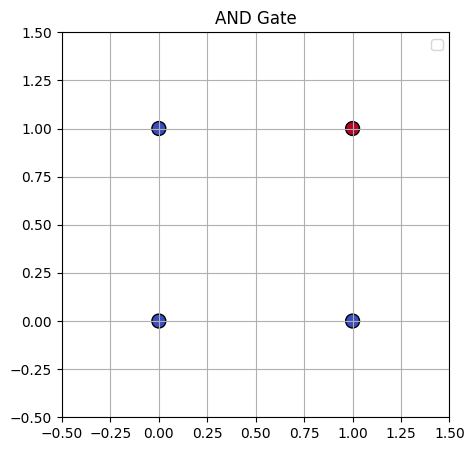

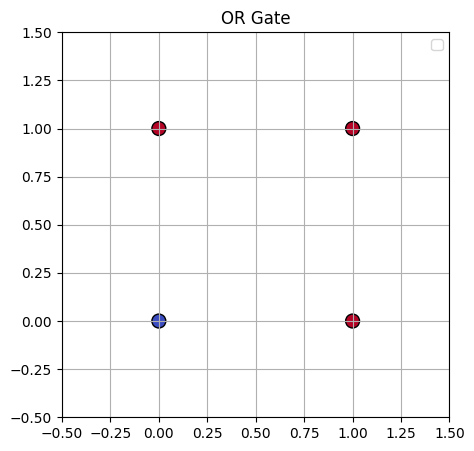

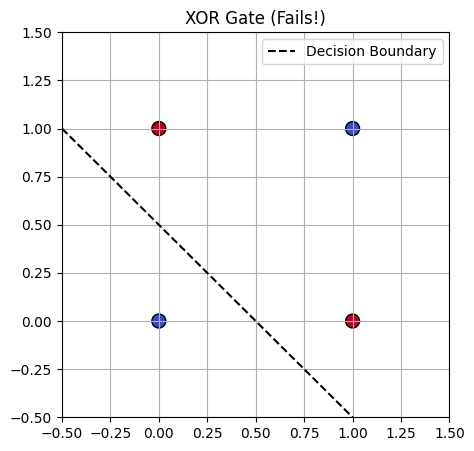

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- HELPER: Decision Boundary Visualizer ---
def visualize(X, y, w, b, title):
    plt.figure(figsize=(5,5))
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', s=100, edgecolors='k')

    # Plot the line: w1*x1 + w2*x2 + b = 0  => x2 = -(w1*x1 + b) / w2
    x_min, x_max = -0.5, 1.5
    x_range = np.linspace(x_min, x_max, 100)
    if w[1] != 0:
        y_range = -(w[0]*x_range + b) / w[1]
        plt.plot(x_range, y_range, 'k--', label='Decision Boundary')

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# --- DATA: Logic Gates ---
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0, 0, 0, 1])
y_or  = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

# TODO 1: Find weights (w) and bias (b) manually that solve AND.
w_and = np.array([0.0, 0.0]) # Change these!
b_and = 0.0                  # Change this!
visualize(X, y_and, w_and, b_and, "AND Gate")

# TODO 2: Find weights (w) and bias (b) manually that solve OR.
w_or = np.array([0.0, 0.0]) # Change these!
b_or = 0.0                  # Change this!
visualize(X, y_or, w_or, b_or, "OR Gate")

# TODO 3: The Failure of XOR.
# Try to find weights... (Spoiler: You can't. It is fundamentally impossible for a straight line).
w_xor = np.array([1.0, 1.0])
b_xor = -0.5
visualize(X, y_xor, w_xor, b_xor, "XOR Gate (Fails!)")

---
## Part 3: Neural Net from Scratch (The "Hard" Way)
To solve XOR, we need to bend space. We do this by adding a "Hidden Layer".

We will write a 2-layer Neural Network purely in NumPy to solve XOR.
**Goal:** Understand Backpropagation by writing the calculus explicitly. If you can do this, PyTorch will feel like magic.

In [18]:
# Input (2) -> Hidden (4) -> Output (1)
input_size, hidden_size, output_size = 2, 4, 1
learning_rate = 0.5

# Initialize Weights (Random normal) and Biases (Zeros)
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a) # Note: 'a' is the already-activated output

losses = []
y_xor_reshaped = y_xor.reshape(-1, 1)

for epoch in range(5000):
    # --- 1. FORWARD PASS ---
    # TODO: Calculate Z1 (Linear) and A1 (Activation)
    Z1 = None
    A1 = None

    # TODO: Calculate Z2 (Linear) and A2 (Activation)
    Z2 = None
    A2 = None

    # Loss: Mean Squared Error
    if A2 is not None:
        loss = np.mean(0.5 * (A2 - y_xor_reshaped)**2)
        losses.append(loss)

    # --- 2. BACKWARD PASS (The Chain Rule!) ---
    if A2 is not None:
        # TODO: Calculate the error at the output layer (dLoss/dZ2)
        dZ2 = (A2 - y_xor_reshaped) * sigmoid_derivative(A2)

        # TODO: Calculate gradients for W2 and b2 (Watch your matrix shapes!)
        dW2 = None
        db2 = None

        # TODO: Propagate error to the hidden layer (dLoss/dZ1)
        dZ1 = None

        # TODO: Calculate gradients for W1 and b1
        dW1 = None
        db1 = None

        # --- 3. UPDATE WEIGHTS (SGD) ---
        if dW1 is not None:
            W1 -= learning_rate * dW1
            b1 -= learning_rate * db1
            W2 -= learning_rate * dW2
            b2 -= learning_rate * db2

    if epoch % 1000 == 0 and A2 is not None:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

if A2 is not None:
    print("\nFinal Predictions for XOR:")
    print(np.round(A2, 3))

---
## Part 4: The "Easy" Way (PyTorch)
Writing backprop manually is crucial for your understanding, but prone to errors. PyTorch handles the gradient calculation for us using a dynamic computation graph called **Autograd**.

Let's solve XOR again, the modern way.

In [19]:
!pip install torch

In [20]:
import torch
import torch.nn as nn

# Convert numpy data to Tensor
X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(y_xor).float().view(-1, 1)

# Define Model using Sequential (LEGO blocks)
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.Sigmoid(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

# Training Loop
for epoch in range(5000):
    # 1. Forward pass
    y_pred = model(X_tensor)
    loss = criterion(y_pred, y_tensor)

    # 2. Backward pass
    optimizer.zero_grad() # Clear old gradients from the graph
    loss.backward()       # MAGIC: PyTorch calculates all gradients automatically
    optimizer.step()      # Update weights

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

print("\nPyTorch Final Predictions:")
print(torch.round(model(X_tensor) * 1000) / 1000)

Epoch 0, Loss: 0.2502
Epoch 1000, Loss: 0.2479
Epoch 2000, Loss: 0.0900
Epoch 3000, Loss: 0.0069
Epoch 4000, Loss: 0.0030

PyTorch Final Predictions:
tensor([[0.0340],
        [0.9540],
        [0.9580],
        [0.0500]], grad_fn=<DivBackward0>)


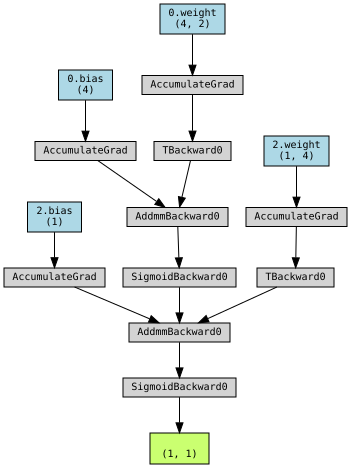

In [22]:
!pip install torchviz
# Note: It also requires the graphviz system library installed on the machine. https://graphviz.org/

from torchviz import make_dot

# 1. We need to pass a dummy input through the network to build the graph
dummy_input = torch.randn(1, 2) # 1 sample, 2 features (like x1, x2)
dummy_output = model(dummy_input)

# 2. Generate the graph
# We pass the output tensor, and the model parameters so it labels the weights (W and b)
computation_graph = make_dot(dummy_output, params=dict(model.named_parameters()))

# 3. Display it right here in the Jupyter Notebook!
computation_graph

---
## Challenge: The "Donut" Problem
XOR is tricky, but what if the data is strictly enclosed? Let's look at concentric circles (a "donut"). A linear classifier would fail completely. We need a Neural Network to essentially "draw a circle" around the inner class.

**Your Task:** Build a PyTorch model to solve this.

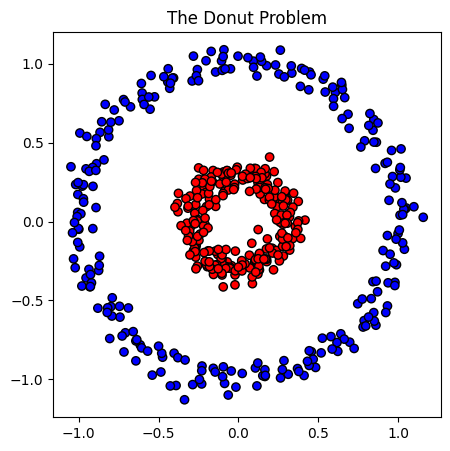

ValueError: optimizer got an empty parameter list

In [23]:
from sklearn.datasets import make_circles

# 1. Generate & Visualize Data
X_np, y_np = make_circles(n_samples=500, factor=0.3, noise=0.05)
X_circ = torch.from_numpy(X_np).float()
y_circ = torch.from_numpy(y_np).float().view(-1, 1)

plt.figure(figsize=(5, 5))
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='bwr', edgecolors='k')
plt.title("The Donut Problem")
plt.show()

# 2. Define Model (Hint: Try nn.Linear(2, 16) -> ReLU -> Linear(16, 16) -> ReLU -> Linear(16,1))
donut_model = nn.Sequential(
    # TODO
)

# 3. Training Setup
optimizer = torch.optim.Adam(donut_model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss() # Binary Cross Entropy

# 4. Write the Training Loop (1000 epochs)
# TODO

print("Training Complete!")


---
## The Hook: Moving to Images (MNIST)
So far, we have only passed 2 numbers into our neural networks ($x_1, x_2$). But the true power of Deep Learning lies in high-dimensional data, like images.

Run the cell below to load the famous **MNIST Digits Dataset**.

We have 1797 images.
Each image is a 8x8 grid of pixels.


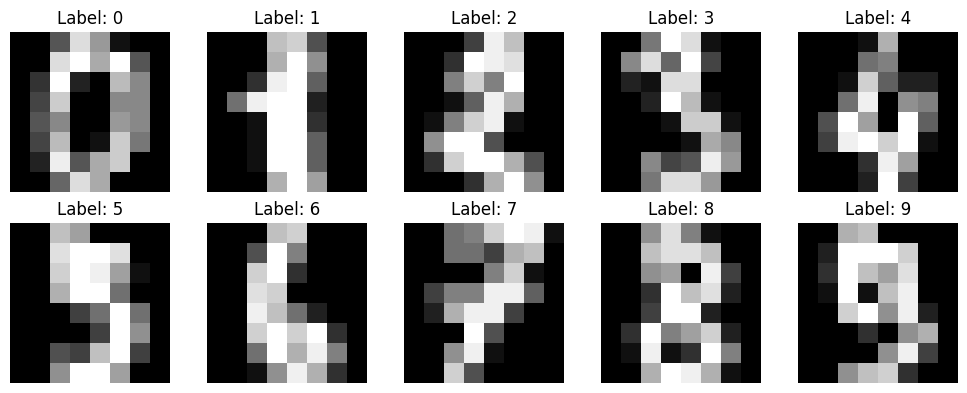

In [24]:
from sklearn.datasets import load_digits

digits = load_digits()
images = digits.images
targets = digits.target

print(f"We have {images.shape[0]} images.")
print(f"Each image is a {images.shape[1]}x{images.shape[2]} grid of pixels.")

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"Label: {targets[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### Your Homework and The Future

To feed these images into the networks we built today, we would have to flatten the 8x8 grid into a 1D vector of 64 numbers. This destroys the spatial information (an eye doesn't look like an eye anymore when it's flattened into a line).

**For your Homework:** You will build a custom object-oriented Deep Learning framework (just like PyTorch) entirely from scratch using NumPy, and you will train it to classify these digits!

**For the Next Lecture:** We will introduce a totally new mathematical operation designed specifically to keep spatial information intact without flattening the images: **Convolutional Neural Networks (CNNs)**.